## 1. 📦 Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Preprocessing
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline

# Models
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# Metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Hyperparameter Tuning
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

# Persistence
import joblib
import os

print('✅ All libraries loaded successfully!')
print(f'   scikit-learn version: {__import__("sklearn").__version__}')

✅ All libraries loaded successfully!
   scikit-learn version: 1.6.1


## 2. 📂 Load and Inspect Dataset

In [ ]:
# Load the feature-engineered dataset
df = pd.read_csv('/content/visa_data_with_features.csv')
df.shape
df.columns.tolist()
df.head()

,country_of_citizenship,class_of_admission,employer_state,us_economic_sector,case_status,foreign_worker_info_education,foreign_worker_info_major,case_received_date,decision_date,processing_days,application_year,month,quarter,dayofweek,country_avg_processing,state_workload,visa_type_avg,is_peak_month
0,INDIA,H-1B,WISCONSIN,UNKNOWN,CERTIFIED,BACHELOR'S,MECHANICAL ENGINEERING,2013-11-19,2015-05-29,556,2013,11,4,1,470.958772,28,469.263606,0
1,SOUTH KOREA,UNKNOWN,MISSISSIPPI,UNKNOWN,DENIED,UNKNOWN,UNKNOWN,2013-11-12,2015-06-26,591,2013,11,4,1,468.054118,17,490.663067,0
2,GERMANY,H-1B,COLORADO,UNKNOWN,DENIED,DOCTORATE,MOLECULAR BIOLOGY,2013-11-27,2014-10-16,323,2013,11,4,2,440.304348,15,469.263606,0
3,SOUTH KOREA,E-2,WASHINGTON,UNKNOWN,CERTIFIED,MASTER'S,BUSINESS ADMINISTRATION,2013-11-13,2015-05-26,559,2013,11,4,2,468.054118,12,475.102484,0
4,SOUTH KOREA,F-1,MICHIGAN,UNKNOWN,CERTIFIED,UNKNOWN,UNKNOWN,2013-11-15,2015-05-28,559,2013,11,4,4,468.054118,22,450.393070,0


In [ ]:
df.info()
df.isnull().sum()
df['processing_days'].describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14622 entries, 0 to 14621
Data columns (total 18 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   country_of_citizenship         14622 non-null  object 
 1   class_of_admission             14622 non-null  object 
 2   employer_state                 14622 non-null  object 
 3   us_economic_sector             14622 non-null  object 
 4   case_status                    14622 non-null  object 
 5   foreign_worker_info_education  14622 non-null  object 
 6   foreign_worker_info_major      14622 non-null  object 
 7   case_received_date             14622 non-null  object 
 8   decision_date                  14622 non-null  object 
 9   processing_days                14622 non-null  int64  
 10  application_year               14622 non-null  int64  
 11  month                          14622 non-null  int64  
 12  quarter                        14622 non-null 

,processing_days
count,14622.000000
mean,470.262618
std,199.688186
min,136.000000
25%,428.000000
50%,490.000000
75%,555.000000
max,1446.000000


## 3. 🔧 Feature Engineering & Preprocessing

In [ ]:
COLS_TO_DROP = [
    'us_economic_sector',
    'foreign_worker_info_major',
    'case_received_date',
    'decision_date'
]

df_model = df.drop(columns=COLS_TO_DROP)
df_model.columns
df_model.columns.tolist()

['country_of_citizenship',
 'class_of_admission',
 'employer_state',
 'case_status',
 'foreign_worker_info_education',
 'processing_days',
 'application_year',
 'month',
 'quarter',
 'dayofweek',
 'country_avg_processing',
 'state_workload',
 'visa_type_avg',
 'is_peak_month']

In [ ]:
# ── Encode case_status as binary (CERTIFIED = 1, DENIED = 0) ─────────────────
df_model['case_status_encoded'] = (df_model['case_status'] == 'CERTIFIED').astype(int)
df_model.drop(columns=['case_status'], inplace=True)

print('case_status → case_status_encoded')
df_model['case_status_encoded'].value_counts()

case_status → case_status_encoded
case_status_encoded
1    11459
0     3163
Name: count, dtype: int64


In [ ]:
# ── Encode high-cardinality categorical columns with Label Encoding ───────────
# For tree-based models (RF, GB) label encoding works well
# For Linear Regression we also create a StandardScaler pipeline

CATEGORICAL_COLS = [
    'country_of_citizenship',
    'class_of_admission',
    'employer_state',
    'foreign_worker_info_education'
]

label_encoders = {}
for col in CATEGORICAL_COLS:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col].astype(str))
    label_encoders[col] = le
    print(f'Encoded {col}: {le.classes_[:5]} ...')

print('\n✅ Label encoding complete!')

Encoded country_of_citizenship: ['AFGHANISTAN' 'ALBANIA' 'ALGERIA' 'ANGOLA' 'ARGENTINA'] ...
Encoded class_of_admission: ['A-3' 'A1/A2' 'B-1' 'B-2' 'C-1'] ...
Encoded employer_state: ['ALABAMA' 'ALASKA' 'ARIZONA' 'ARKANSAS' 'CALIFORNIA'] ...
Encoded foreign_worker_info_education: ["ASSOCIATE'S" "BACHELOR'S" 'DOCTORATE' 'HIGH SCHOOL' "MASTER'S"] ...

✅ Label encoding complete!


In [ ]:
# ── Define Feature Matrix (X) and Target Vector (y) ──────────────────────────
TARGET = 'processing_days'

FEATURE_COLS = [
    'country_of_citizenship',
    'class_of_admission',
    'employer_state',
    'foreign_worker_info_education',
    'case_status_encoded',
    'application_year',
    'month',
    'quarter',
    'dayofweek',
    'country_avg_processing',
    'state_workload',
    'visa_type_avg',
    'is_peak_month'
]

X = df_model[FEATURE_COLS]
y = df_model[TARGET]

print(f'Feature matrix shape : {X.shape}')
print(f'Target vector shape  : {y.shape}')
print(f'\nFeatures: {FEATURE_COLS}')
X.describe()

Feature matrix shape : (14622, 13)
Target vector shape  : (14622,)

Features: ['country_of_citizenship', 'class_of_admission', 'employer_state', 'foreign_worker_info_education', 'case_status_encoded', 'application_year', 'month', 'quarter', 'dayofweek', 'country_avg_processing', 'state_workload', 'visa_type_avg', 'is_peak_month']


,country_of_citizenship,class_of_admission,employer_state,foreign_worker_info_education,case_status_encoded,application_year,month,quarter,dayofweek,country_avg_processing,state_workload,visa_type_avg,is_peak_month
count,14622.000000,14622.000000,14622.000000,14622.000000,14622.000000,14622.000000,14622.000000,14622.000000,14622.000000,14622.000000,14622.000000,14622.000000,14622.000000
mean,70.608056,18.323143,22.793052,3.155040,0.783682,2013.606415,7.084325,2.675010,2.131856,470.262618,87.832034,470.262618,0.632061
std,30.959400,7.910000,16.662240,1.745827,0.411748,0.642089,3.660990,1.171197,1.560441,25.133927,103.714090,18.157786,0.482261
min,0.000000,0.000000,0.000000,0.000000,0.000000,2010.000000,1.000000,1.000000,0.000000,168.000000,1.000000,285.666667,0.000000
25%,61.000000,16.000000,4.000000,1.000000,1.000000,2013.000000,4.000000,2.000000,1.000000,461.333333,16.000000,469.263606,0.000000
50%,61.000000,16.000000,22.000000,4.000000,1.000000,2014.000000,7.000000,3.000000,2.000000,470.958772,45.000000,469.263606,1.000000
75%,97.000000,16.000000,36.000000,4.000000,1.000000,2014.000000,11.000000,4.000000,3.000000,470.958772,107.000000,469.263606,1.000000
max,142.000000,40.000000,54.000000,6.000000,1.000000,2015.000000,12.000000,4.000000,6.000000,812.000000,454.000000,598.000000,1.000000


In [ ]:
# ── Train / Test Split (80 / 20) ─────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42
)

print(f'Training set   : {X_train.shape[0]:,} samples')
print(f'Test set       : {X_test.shape[0]:,} samples')
print(f'\nTarget distribution (train):')
print(y_train.describe())

Training set   : 11,697 samples
Test set       : 2,925 samples

Target distribution (train):
count    11697.000000
mean       469.543045
std        199.080102
min        138.000000
25%        428.000000
50%        490.000000
75%        554.000000
max       1446.000000
Name: processing_days, dtype: float64


In [ ]:
# ── Scale features for Linear Regression ─────────────────────────────────────
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print('✅ Feature scaling done (used only for Linear Regression).')

✅ Feature scaling done (used only for Linear Regression).


## 4. 📊 Helper — Evaluation Utilities

In [ ]:
def evaluate_model(name, model, X_tr, y_tr, X_te, y_te, scaled=False):
    model.fit(X_tr, y_tr)
    preds = model.predict(X_te)

    mae  = mean_absolute_error(y_te, preds)
    rmse = np.sqrt(mean_squared_error(y_te, preds))
    r2   = r2_score(y_te, preds)

    # 5-fold CV R² on training data
    cv_r2 = cross_val_score(model, X_tr, y_tr, cv=5,
                            scoring='r2', n_jobs=-1).mean()

    print(f'\n{'═'*50}')
    print(f'  Model : {name}')
    print(f'  MAE   : {mae:.2f} days')
    print(f'  RMSE  : {rmse:.2f} days')
    print(f'  R²    : {r2:.4f}')
    print(f'  CV R² : {cv_r2:.4f}  (5-fold, train)')
    print(f'{'═'*50}')

    return {
        'Model': name,
        'MAE':   round(mae,  2),
        'RMSE':  round(rmse, 2),
        'R2':    round(r2,   4),
        'CV_R2': round(cv_r2, 4),
        'predictions': preds
    }


def plot_residuals(name, y_true, y_pred):
    residuals = y_true.values - y_pred
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f'Residual Analysis — {name}', fontsize=14, fontweight='bold')

    # Actual vs Predicted
    axes[0].scatter(y_true, y_pred, alpha=0.35, color='steelblue', edgecolors='none', s=20)
    lims = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
    axes[0].plot(lims, lims, 'r--', lw=1.5)
    axes[0].set_xlabel('Actual Processing Days')
    axes[0].set_ylabel('Predicted Processing Days')
    axes[0].set_title('Actual vs Predicted')

    # Residuals vs Predicted
    axes[1].scatter(y_pred, residuals, alpha=0.35, color='darkorange', edgecolors='none', s=20)
    axes[1].axhline(0, color='red', lw=1.5, linestyle='--')
    axes[1].set_xlabel('Predicted Processing Days')
    axes[1].set_ylabel('Residuals')
    axes[1].set_title('Residuals vs Predicted')

    # Residual Distribution
    axes[2].hist(residuals, bins=50, color='seagreen', edgecolor='white', alpha=0.8)
    axes[2].axvline(0, color='red', lw=1.5, linestyle='--')
    axes[2].set_xlabel('Residual')
    axes[2].set_ylabel('Frequency')
    axes[2].set_title('Residual Distribution')

    plt.tight_layout()
    plt.savefig(f'residuals_{name.replace(" ", "_")}.png', dpi=120)
    plt.show()


print('✅ Helper functions defined.')

✅ Helper functions defined.


## 5. 🔵 Model 1 — Linear Regression (Baseline)

In [ ]:
# ──  Ordinary Linear Regression ──────────────────────────────────────────
lr_model = LinearRegression()
lr_results = evaluate_model(
    'Linear Regression',
    lr_model,
    X_train_scaled, y_train,
    X_test_scaled,  y_test
)


══════════════════════════════════════════════════
  Model : Linear Regression
  MAE   : 43.81 days
  RMSE  : 59.91 days
  R²    : 0.9121
  CV R² : 0.9116  (5-fold, train)
══════════════════════════════════════════════════


In [ ]:
# ── Regularised variants (Ridge / Lasso) ─────────────────────────────────
# Ridge (L2)
ridge_params = {'alpha': [0.1, 1.0, 10.0, 50.0, 100.0]}
ridge_cv = GridSearchCV(Ridge(), ridge_params, cv=5, scoring='r2', n_jobs=-1)
ridge_cv.fit(X_train_scaled, y_train)
print(f'Best Ridge alpha: {ridge_cv.best_params_}')
ridge_results = evaluate_model(
    'Ridge Regression',
    ridge_cv.best_estimator_,
    X_train_scaled, y_train,
    X_test_scaled,  y_test
)

# Lasso (L1)
lasso_params = {'alpha': [0.1, 1.0, 10.0, 50.0, 100.0]}
lasso_cv = GridSearchCV(Lasso(max_iter=5000), lasso_params, cv=5, scoring='r2', n_jobs=-1)
lasso_cv.fit(X_train_scaled, y_train)
print(f'Best Lasso alpha: {lasso_cv.best_params_}')
lasso_results = evaluate_model(
    'Lasso Regression',
    lasso_cv.best_estimator_,
    X_train_scaled, y_train,
    X_test_scaled,  y_test
)

Best Ridge alpha: {'alpha': 1.0}

══════════════════════════════════════════════════
  Model : Ridge Regression
  MAE   : 43.81 days
  RMSE  : 59.91 days
  R²    : 0.9121
  CV R² : 0.9116  (5-fold, train)
══════════════════════════════════════════════════
Best Lasso alpha: {'alpha': 0.1}

══════════════════════════════════════════════════
  Model : Lasso Regression
  MAE   : 43.85 days
  RMSE  : 59.94 days
  R²    : 0.9120
  CV R² : 0.9116  (5-fold, train)
══════════════════════════════════════════════════


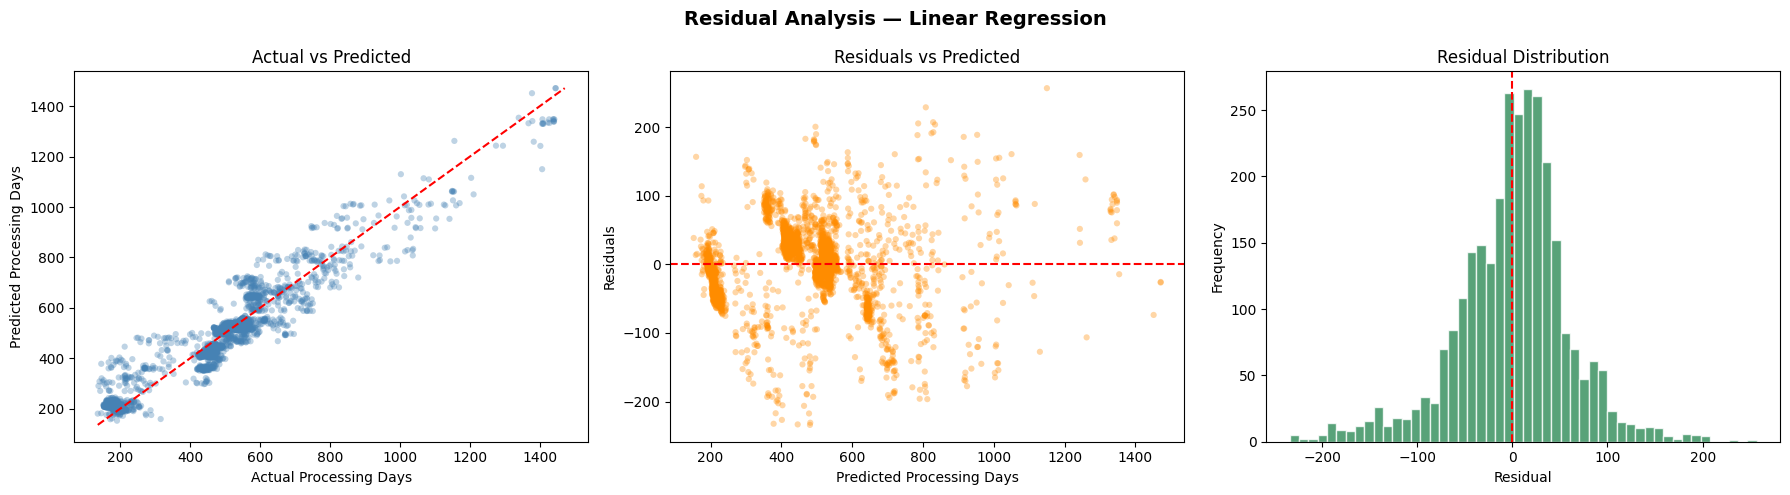

In [ ]:
# ──  Visualise Linear Regression residuals ────────────────────────────────
plot_residuals('Linear Regression', y_test, lr_results['predictions'])

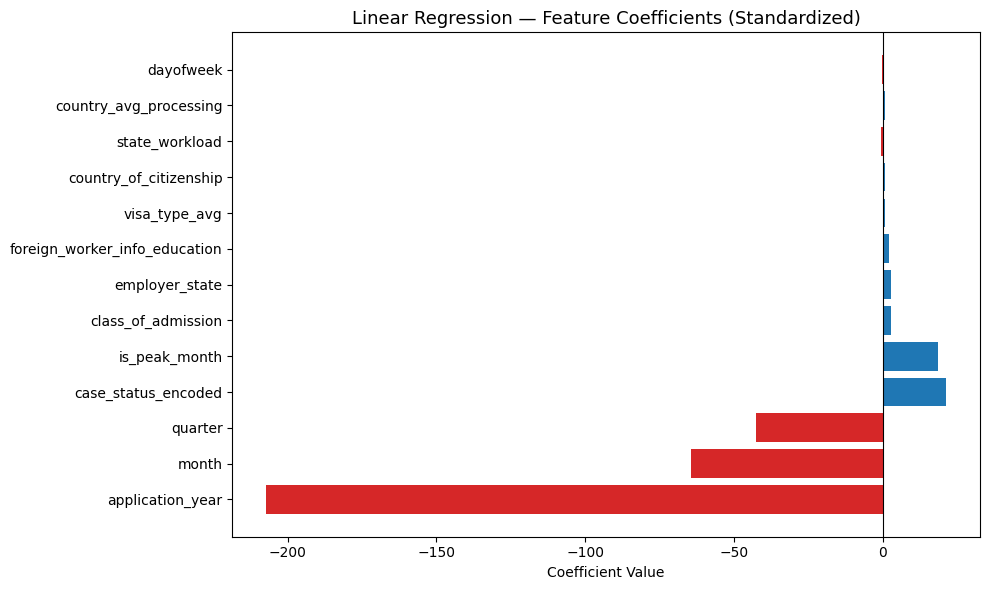

In [ ]:
# ──  Feature Coefficients ─────────────────────────────────────────────────
coef_df = pd.DataFrame({
    'Feature': FEATURE_COLS,
    'Coefficient': lr_model.coef_
}).sort_values('Coefficient', key=abs, ascending=False)

plt.figure(figsize=(10, 6))
colors = ['#d62728' if c < 0 else '#1f77b4' for c in coef_df['Coefficient']]
plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors)
plt.axvline(0, color='black', lw=0.8)
plt.title('Linear Regression — Feature Coefficients (Standardized)', fontsize=13)
plt.xlabel('Coefficient Value')
plt.tight_layout()
plt.savefig('lr_coefficients.png', dpi=120)
plt.show()

## 6. 🌲 Model 2 — Random Forest Regressor

In [ ]:
# ── Baseline Random Forest (uses raw un-scaled features) ─────────────────
rf_base = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)
rf_base_results = evaluate_model(
    'Random Forest (baseline)',
    rf_base,
    X_train, y_train,
    X_test,  y_test
)


══════════════════════════════════════════════════
  Model : Random Forest (baseline)
  MAE   : 27.40 days
  RMSE  : 49.70 days
  R²    : 0.9395
  CV R² : 0.9412  (5-fold, train)
══════════════════════════════════════════════════


In [ ]:
# ──  Hyperparameter Tuning — RandomizedSearchCV ───────────────────────────
rf_param_grid = {
    'n_estimators'     : [100, 200, 300],
    'max_depth'        : [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf' : [1, 2, 4],
    'max_features'     : ['sqrt', 'log2', 0.5]
}

rf_search = RandomizedSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    param_distributions=rf_param_grid,
    n_iter=30,
    cv=5,
    scoring='r2',
    verbose=1,
    random_state=42,
    n_jobs=-1
)

print('Tuning Random Forest … ')
rf_search.fit(X_train, y_train)
print(f'\nBest params: {rf_search.best_params_}')
print(f'Best CV R²  : {rf_search.best_score_:.4f}')

Tuning Random Forest … (this may take ~2–3 minutes)
Fitting 5 folds for each of 30 candidates, totalling 150 fits

Best params: {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 0.5, 'max_depth': 10}
Best CV R²  : 0.9464


In [ ]:
# ── Evaluate Tuned Random Forest ────────────────────────────────────────
rf_best = rf_search.best_estimator_
rf_results = evaluate_model(
    'Random Forest (tuned)',
    rf_best,
    X_train, y_train,
    X_test,  y_test
)


══════════════════════════════════════════════════
  Model : Random Forest (tuned)
  MAE   : 27.18 days
  RMSE  : 48.34 days
  R²    : 0.9428
  CV R² : 0.9464  (5-fold, train)
══════════════════════════════════════════════════


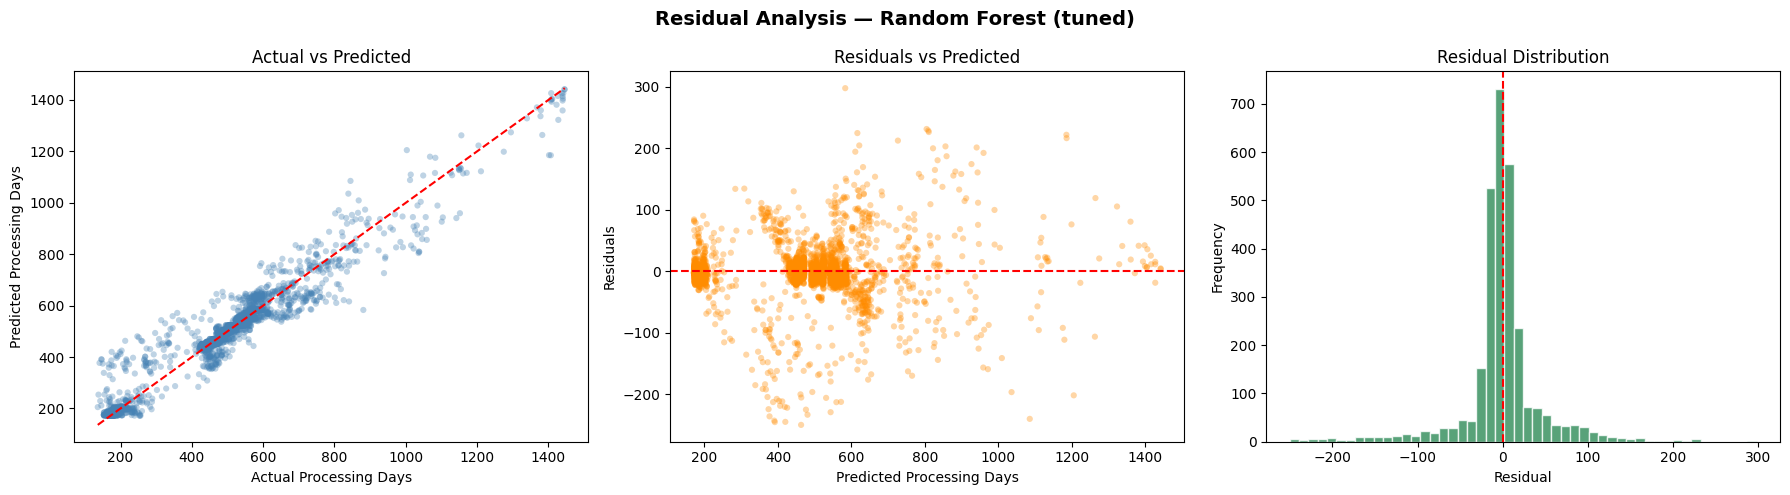

In [ ]:
# ── Residual plots ───────────────────────────────────────────────────────
plot_residuals('Random Forest (tuned)', y_test, rf_results['predictions'])

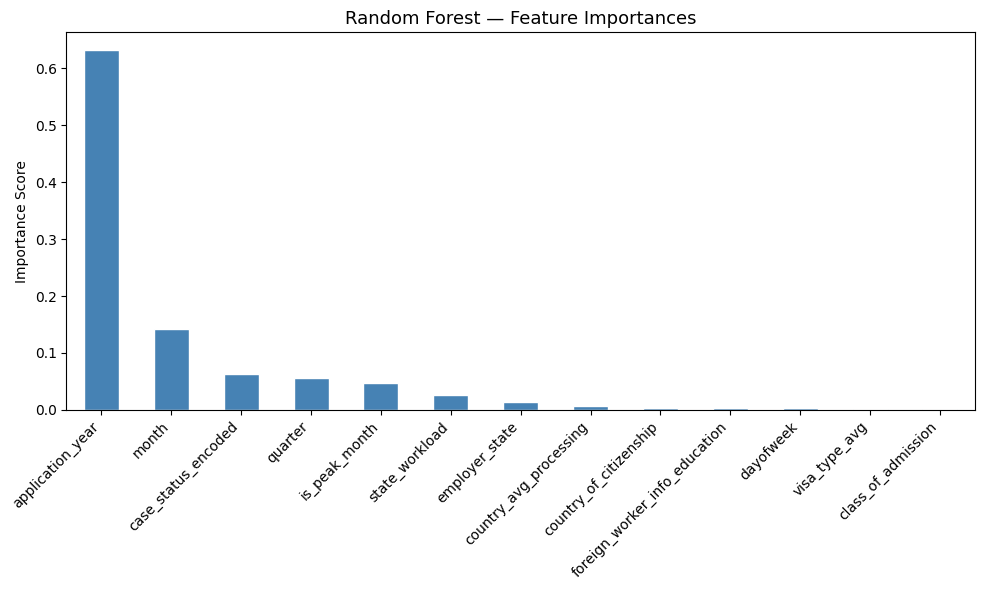

application_year                 0.631562
month                            0.141475
case_status_encoded              0.062370
quarter                          0.056267
is_peak_month                    0.046655
state_workload                   0.026424
employer_state                   0.014319
country_avg_processing           0.006197
country_of_citizenship           0.004157
foreign_worker_info_education    0.003284
dayofweek                        0.003045
visa_type_avg                    0.002286
class_of_admission               0.001961
dtype: float64


In [ ]:
# ── Feature Importance ───────────────────────────────────────────────────
importances = pd.Series(rf_best.feature_importances_, index=FEATURE_COLS)
importances = importances.sort_values(ascending=False)

plt.figure(figsize=(10, 6))
importances.plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Random Forest — Feature Importances', fontsize=13)
plt.ylabel('Importance Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('rf_feature_importance.png', dpi=120)
plt.show()

print(importances)

## 7. 🚀 Model 3 — Gradient Boosting Regressor

In [ ]:
# ──  Baseline Gradient Boosting ──────────────────────────────────────────
gb_base = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=4,
    random_state=42
)
gb_base_results = evaluate_model(
    'Gradient Boosting (baseline)',
    gb_base,
    X_train, y_train,
    X_test,  y_test
)


══════════════════════════════════════════════════
  Model : Gradient Boosting (baseline)
  MAE   : 28.44 days
  RMSE  : 49.95 days
  R²    : 0.9389
  CV R² : 0.9444  (5-fold, train)
══════════════════════════════════════════════════


In [ ]:
# ── 7.2  Hyperparameter Tuning — GridSearchCV ─────────────────────────────────
gb_param_grid = {
    'n_estimators'  : [100, 200, 300],
    'learning_rate' : [0.05, 0.1, 0.15],
    'max_depth'     : [3, 4, 5],
    'subsample'     : [0.7, 0.85, 1.0],
    'min_samples_split': [2, 5]
}

gb_search = RandomizedSearchCV(
    GradientBoostingRegressor(random_state=42),
    param_distributions=gb_param_grid,
    n_iter=25,
    cv=5,
    scoring='r2',
    verbose=1,
    random_state=42,
    n_jobs=-1
)

print('Tuning Gradient Boosting … (this may take ~3–5 minutes)')
gb_search.fit(X_train, y_train)
print(f'\nBest params: {gb_search.best_params_}')
print(f'Best CV R²  : {gb_search.best_score_:.4f}')

Tuning Gradient Boosting … (this may take ~3–5 minutes)
Fitting 5 folds for each of 25 candidates, totalling 125 fits

Best params: {'subsample': 1.0, 'n_estimators': 100, 'min_samples_split': 5, 'max_depth': 5, 'learning_rate': 0.1}
Best CV R²  : 0.9452


In [ ]:
# ──  Evaluate Tuned Gradient Boosting ─────────────────────────────────────
gb_best = gb_search.best_estimator_
gb_results = evaluate_model(
    'Gradient Boosting (tuned)',
    gb_best,
    X_train, y_train,
    X_test,  y_test
)


══════════════════════════════════════════════════
  Model : Gradient Boosting (tuned)
  MAE   : 27.78 days
  RMSE  : 48.96 days
  R²    : 0.9413
  CV R² : 0.9452  (5-fold, train)
══════════════════════════════════════════════════


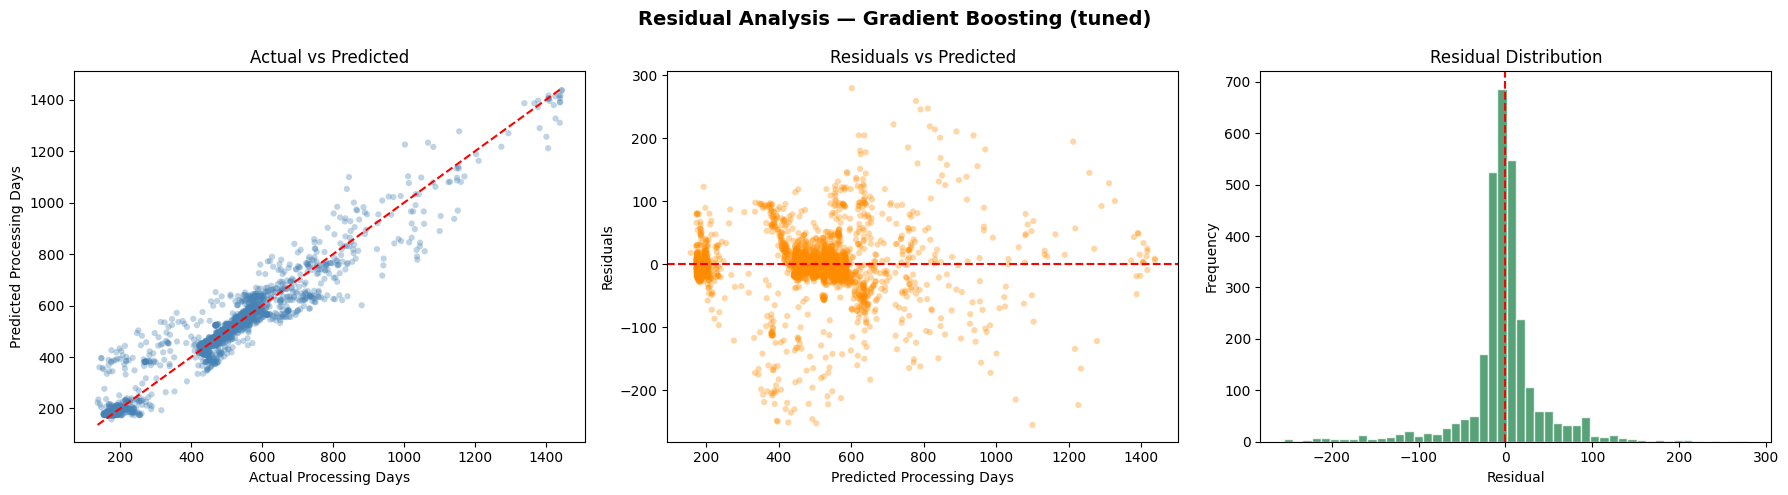

In [ ]:
# ── Residual plots ───────────────────────────────────────────────────────
plot_residuals('Gradient Boosting (tuned)', y_test, gb_results['predictions'])

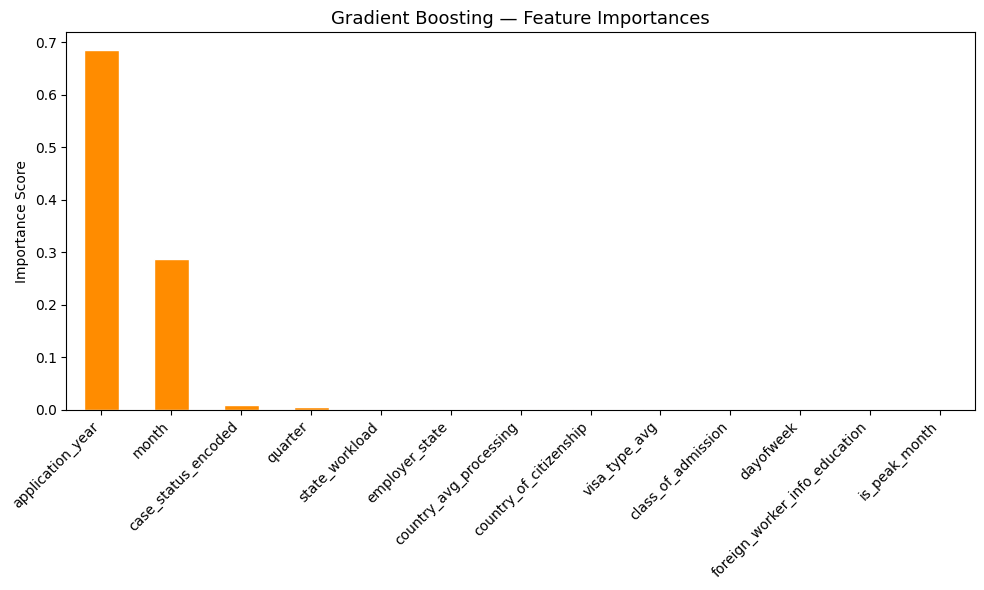

application_year                 0.684485
month                            0.287669
case_status_encoded              0.010164
quarter                          0.006528
state_workload                   0.002324
employer_state                   0.001951
country_avg_processing           0.001725
country_of_citizenship           0.001484
visa_type_avg                    0.001075
class_of_admission               0.000676
dayofweek                        0.000659
foreign_worker_info_education    0.000649
is_peak_month                    0.000610
dtype: float64


In [ ]:
# ──   Feature Importance ───────────────────────────────────────────────────
gb_importances = pd.Series(gb_best.feature_importances_, index=FEATURE_COLS)
gb_importances = gb_importances.sort_values(ascending=False)

plt.figure(figsize=(10, 6))
gb_importances.plot(kind='bar', color='darkorange', edgecolor='white')
plt.title('Gradient Boosting — Feature Importances', fontsize=13)
plt.ylabel('Importance Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('gb_feature_importance.png', dpi=120)
plt.show()

print(gb_importances)

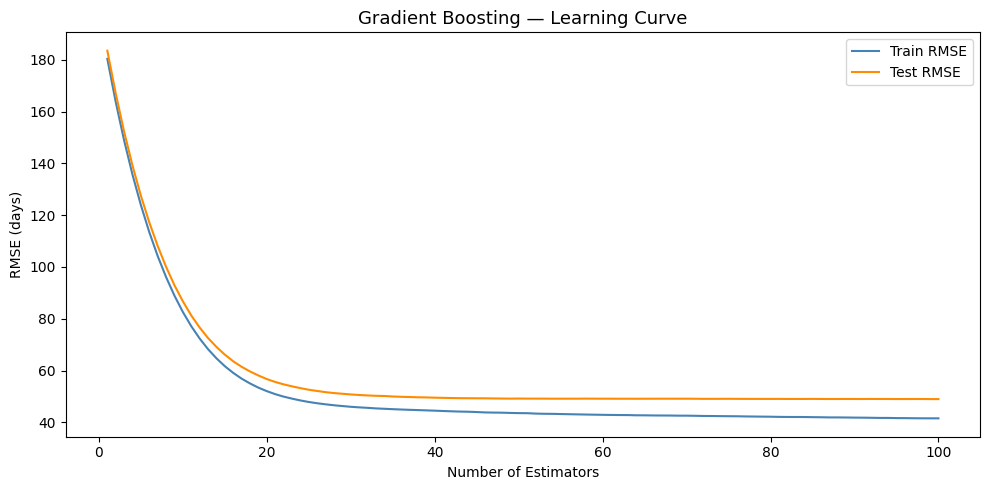

In [ ]:
# ──  Deviance (Training vs Validation Loss) ───────────────────────────────
n_estimators_range = np.arange(1, gb_best.n_estimators_ + 1)

train_errors = [mean_squared_error(y_train, y_pred)
                for y_pred in gb_best.staged_predict(X_train)]
test_errors  = [mean_squared_error(y_test, y_pred)
                for y_pred in gb_best.staged_predict(X_test)]

plt.figure(figsize=(10, 5))
plt.plot(n_estimators_range, np.sqrt(train_errors), label='Train RMSE', color='steelblue')
plt.plot(n_estimators_range, np.sqrt(test_errors),  label='Test RMSE',  color='darkorange')
plt.xlabel('Number of Estimators')
plt.ylabel('RMSE (days)')
plt.title('Gradient Boosting — Learning Curve', fontsize=13)
plt.legend()
plt.tight_layout()
plt.savefig('gb_learning_curve.png', dpi=120)
plt.show()

## 8. 📈 Model Comparison Dashboard

In [ ]:
# ── Summary Table ───────────────────────
results_summary = pd.DataFrame([
    {k: v for k, v in lr_results.items()    if k != 'predictions'},
    {k: v for k, v in ridge_results.items() if k != 'predictions'},
    {k: v for k, v in lasso_results.items() if k != 'predictions'},
    {k: v for k, v in rf_base_results.items()  if k != 'predictions'},
    {k: v for k, v in rf_results.items()    if k != 'predictions'},
    {k: v for k, v in gb_base_results.items()  if k != 'predictions'},
    {k: v for k, v in gb_results.items()    if k != 'predictions'},
]).set_index('Model')

def highlight_best(s):
    if s.name in ('MAE', 'RMSE'):
        best = s.min()
    else:
        best = s.max()
    return ['background-color: #d4edda; font-weight: bold'
            if v == best else '' for v in s]

print('\n===  MODEL COMPARISON  ===')
results_summary.style.apply(highlight_best)


===  MODEL COMPARISON  ===


,MAE,RMSE,R2,CV_R2
Model,,,,
Linear Regression,43.810000,59.910000,0.912100,0.911600
Ridge Regression,43.810000,59.910000,0.912100,0.911600
Lasso Regression,43.850000,59.940000,0.912000,0.911600
Random Forest (baseline),27.400000,49.700000,0.939500,0.941200
Random Forest (tuned),27.180000,48.340000,0.942800,0.946400
Gradient Boosting (baseline),28.440000,49.950000,0.938900,0.944400
Gradient Boosting (tuned),27.780000,48.960000,0.941300,0.945200


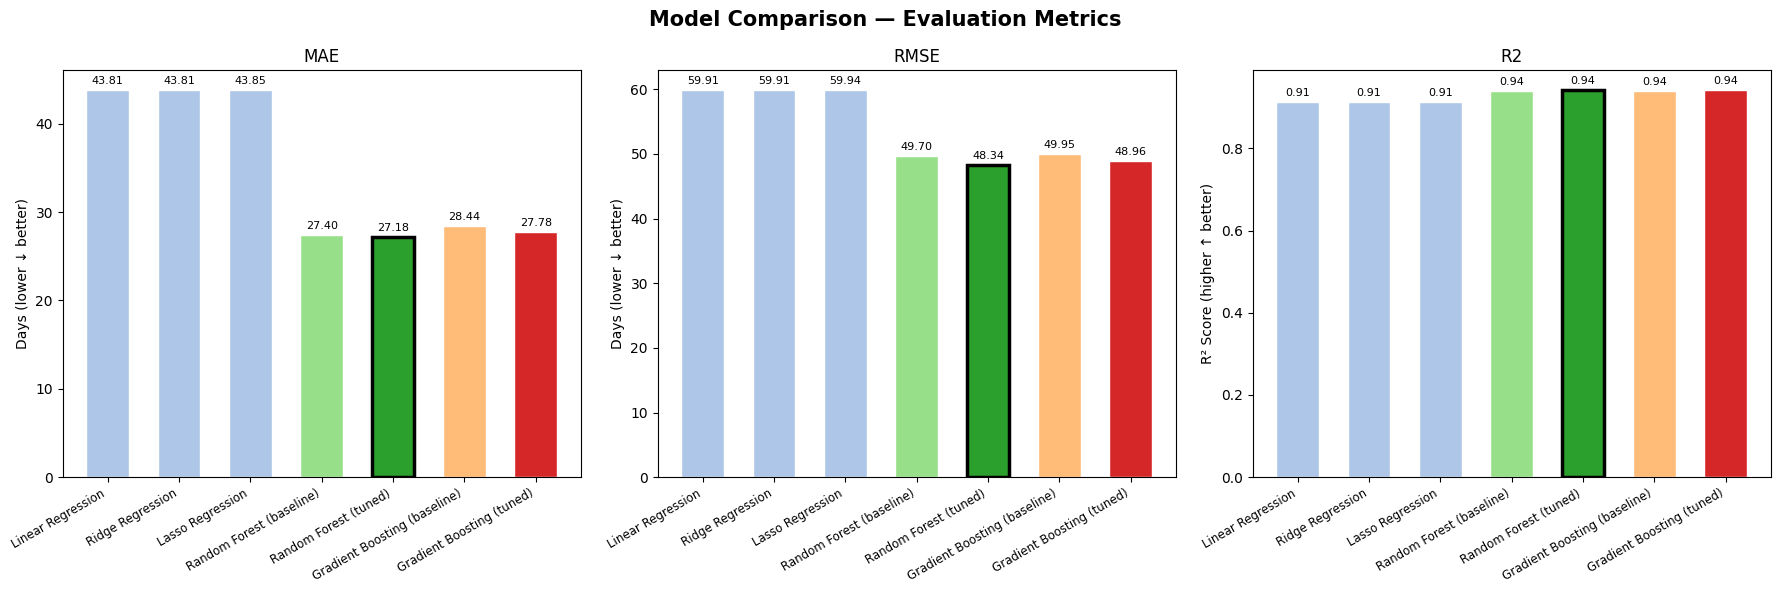

In [ ]:
# ── Side-by-side bar charts ─────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Model Comparison — Evaluation Metrics', fontsize=15, fontweight='bold')

colors = ['#aec7e8', '#aec7e8', '#aec7e8',
          '#98df8a', '#2ca02c',
          '#ffbb78', '#d62728']

models = results_summary.index.tolist()
x = np.arange(len(models))

for ax, metric, ylabel, best_fn in [
    (axes[0], 'MAE',  'Days (lower ↓ better)', 'min'),
    (axes[1], 'RMSE', 'Days (lower ↓ better)', 'min'),
    (axes[2], 'R2',   'R² Score (higher ↑ better)', 'max')
]:
    vals = results_summary[metric].values
    bars = ax.bar(x, vals, color=colors, edgecolor='white', width=0.6)
    best_idx = int(np.argmin(vals) if best_fn == 'min' else np.argmax(vals))
    bars[best_idx].set_edgecolor('black')
    bars[best_idx].set_linewidth(2.5)
    ax.set_xticks(x)
    ax.set_xticklabels(models, rotation=30, ha='right', fontsize=8.5)
    ax.set_title(metric, fontsize=12)
    ax.set_ylabel(ylabel)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.01 * max(vals),
                f'{val:.2f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=130)
plt.show()

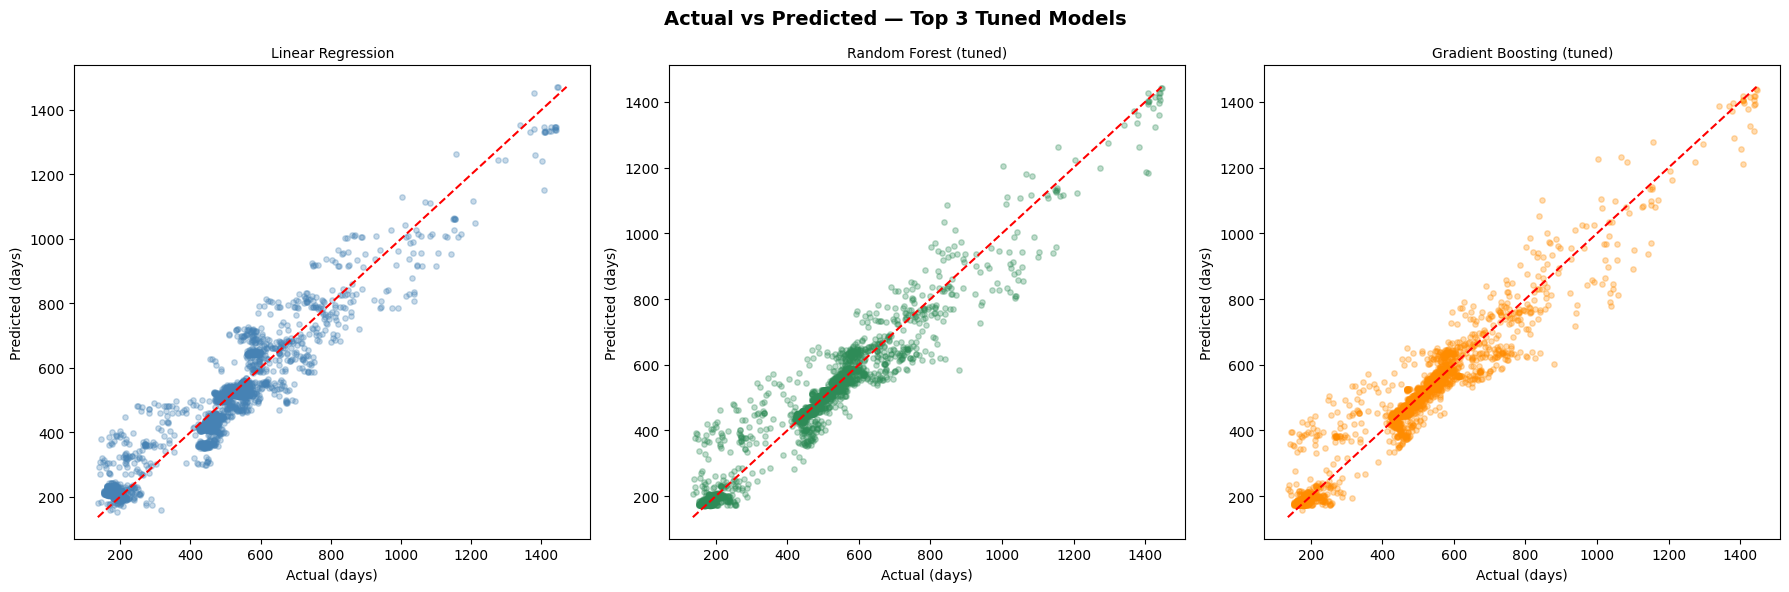

In [ ]:
# ── Prediction Overlay ─────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Actual vs Predicted — Top 3 Tuned Models', fontsize=14, fontweight='bold')

for ax, (name, preds, color) in zip(axes, [
    ('Linear Regression',        lr_results['predictions'],  'steelblue'),
    ('Random Forest (tuned)',    rf_results['predictions'],  'seagreen'),
    ('Gradient Boosting (tuned)',gb_results['predictions'],  'darkorange')
]):
    ax.scatter(y_test, preds, alpha=0.3, s=15, color=color)
    lims = [min(y_test.min(), preds.min()), max(y_test.max(), preds.max())]
    ax.plot(lims, lims, 'r--', lw=1.5)
    ax.set_xlabel('Actual (days)')
    ax.set_ylabel('Predicted (days)')
    ax.set_title(name, fontsize=10)

plt.tight_layout()
plt.savefig('actual_vs_predicted.png', dpi=130)
plt.show()

## 9. 🏆 Best Model — Cross Validation Deep Dive

In [ ]:
# ── Identify best model by R² ───────────
best_model_name = results_summary['R2'].idxmax()
print(f'🏆 Best model by R²: {best_model_name}')
print(results_summary.loc[best_model_name])

model_registry = {
    'Linear Regression'          : lr_model,
    'Ridge Regression'           : ridge_cv.best_estimator_,
    'Lasso Regression'           : lasso_cv.best_estimator_,
    'Random Forest (baseline)'   : rf_base,
    'Random Forest (tuned)'      : rf_best,
    'Gradient Boosting (baseline)': gb_base,
    'Gradient Boosting (tuned)'  : gb_best,
}
best_model = model_registry[best_model_name]

🏆 Best model by R²: Random Forest (tuned)
MAE      27.1800
RMSE     48.3400
R2        0.9428
CV_R2     0.9464
Name: Random Forest (tuned), dtype: float64



10-Fold CV Results — Random Forest (tuned)
MAE  : 25.98 ± 1.21
RMSE : 45.94 ± 2.16
R²   : 0.9464 ± 0.0051


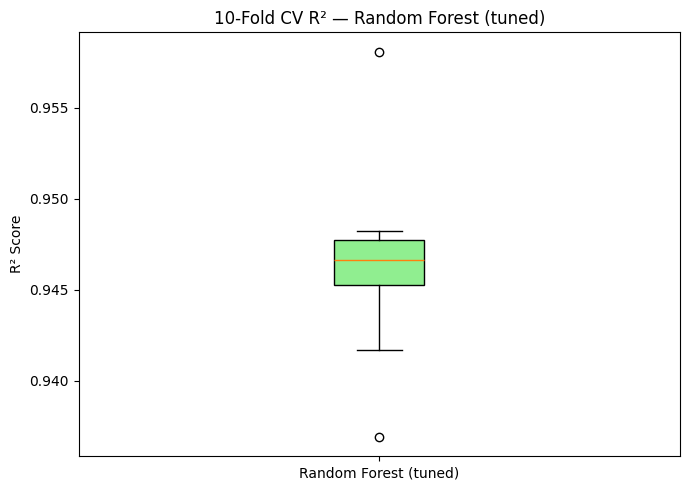

In [ ]:
# ── 10-fold Cross Validation on the best model ────────────────────────────────
kf = KFold(n_splits=10, shuffle=True, random_state=42)
use_scaled = best_model_name in ('Linear Regression', 'Ridge Regression', 'Lasso Regression')
X_cv = X_train_scaled if use_scaled else X_train

cv_mae  = -cross_val_score(best_model, X_cv, y_train, cv=kf,
                           scoring='neg_mean_absolute_error', n_jobs=-1)
cv_rmse = np.sqrt(-cross_val_score(best_model, X_cv, y_train, cv=kf,
                                   scoring='neg_mean_squared_error', n_jobs=-1))
cv_r2   = cross_val_score(best_model, X_cv, y_train, cv=kf,
                          scoring='r2', n_jobs=-1)

print(f'\n10-Fold CV Results — {best_model_name}')
print(f'MAE  : {cv_mae.mean():.2f} ± {cv_mae.std():.2f}')
print(f'RMSE : {cv_rmse.mean():.2f} ± {cv_rmse.std():.2f}')
print(f'R²   : {cv_r2.mean():.4f} ± {cv_r2.std():.4f}')

# Boxplot of CV R² scores
plt.figure(figsize=(7, 5))
plt.boxplot([cv_r2], labels=[best_model_name], patch_artist=True,
            boxprops=dict(facecolor='lightgreen', color='black'))
plt.ylabel('R² Score')
plt.title(f'10-Fold CV R² — {best_model_name}', fontsize=12)
plt.tight_layout()
plt.savefig('cv_r2_boxplot.png', dpi=120)
plt.show()

## 10. 💾 Save Models & Artefacts

In [ ]:
os.makedirs('saved_models', exist_ok=True)

# Save all tuned models
joblib.dump(ridge_cv.best_estimator_,'saved_models/ridge_regression.pkl')
joblib.dump(rf_best,'saved_models/random_forest_tuned.pkl')
joblib.dump(gb_best,'saved_models/gradient_boosting_tuned.pkl')
joblib.dump(scaler,'saved_models/scaler.pkl')

joblib.dump(label_encoders,'saved_models/label_encoders.pkl')

# Save best model separately
joblib.dump(best_model,'saved_models/best_model.pkl')

# Save results summary
results_summary.to_csv('saved_models/model_comparison_results.csv')


## 11. 🔍 Inference — Predict for a New Application

In [ ]:
def predict_processing_time(application: dict) -> dict:
    # Load artefacts
    model = joblib.load('saved_models/best_model.pkl')
    les   = joblib.load('saved_models/label_encoders.pkl')

    row = pd.DataFrame([application])

    # Encode categoricals
    for col, le in les.items():
        if col in row.columns:
            # Handle unseen labels gracefully
            val = str(row[col].iloc[0])
            if val in le.classes_:
                row[col] = le.transform([val])
            else:
                row[col] = -1

    X_input = row[FEATURE_COLS]
    pred    = model.predict(X_input)[0]

    # Approximate ±1 std interval based on training residuals
    MAE_BEST = results_summary.loc[best_model_name, 'MAE']
    return {
        'predicted_days': round(pred),
        'lower_bound'   : round(pred - MAE_BEST),
        'upper_bound'   : round(pred + MAE_BEST),
    }


# ── Example inference ───────────────
sample_application = {
    'country_of_citizenship'     : 'INDIA',
    'class_of_admission'         : 'H-1B',
    'employer_state'             : 'CALIFORNIA',
    'foreign_worker_info_education': "MASTER'S",
    'case_status_encoded'        : 1,
    'application_year'           : 2024,
    'month'                      : 6,
    'quarter'                    : 2,
    'dayofweek'                  : 0,
    'country_avg_processing'     : 471.0,
    'state_workload'             : 30,
    'visa_type_avg'              : 469.0,
    'is_peak_month'              : 1
}

result = predict_processing_time(sample_application)
print(f"\n📋 Sample Prediction")
print(f"   Applicant   : {sample_application['country_of_citizenship']} / {sample_application['class_of_admission']}")
print(f"   Predicted   : {result['predicted_days']} days")
print(f"   Range       : {result['lower_bound']} – {result['upper_bound']} days")


📋 Sample Prediction
   Applicant   : INDIA / H-1B
   Predicted   : 250 days
   Range       : 223 – 278 days
